# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


# Load libraries

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import random
import pickle


# Data preprocessing

C:\Users\anuhe\AppData\Local\Temp\ipykernel_10024\865673496.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_10024\865673496.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functio

      velocity    mass  deceleration_average
0           21  1341.0             -4.874774
1           21  1341.0             -4.868881
2           20  1341.0             -5.098785
3           20  1341.0             -5.059594
4           20  1341.0             -4.774860
...        ...     ...                   ...
4048        20  1530.0             -4.794934
4049        20  1530.0             -5.272853
4050        20  1530.0             -4.844974
4051        20  1530.0             -5.327936
4052        20  1530.0             -5.029897

[4053 rows x 3 columns]
           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          

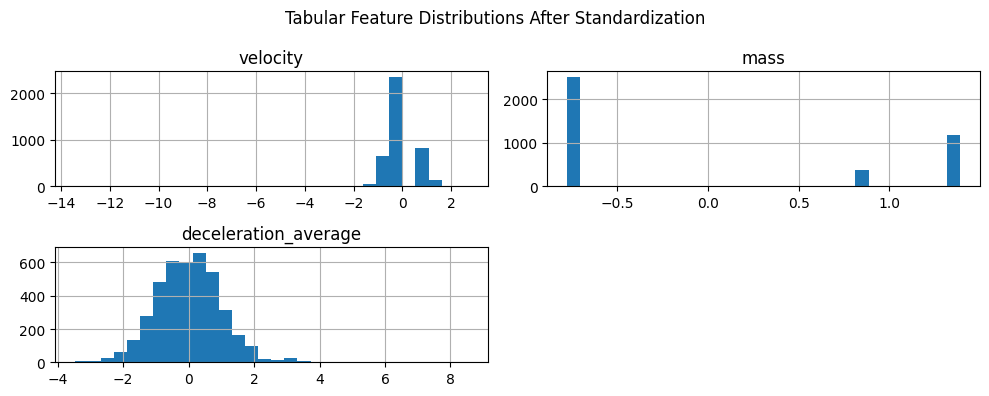

                ch_0           ch_1           ch_2           ch_3  \
count  518784.000000  518784.000000  518784.000000  518784.000000   
mean       -2.845372      -0.049401      -0.057974       0.058683   
std         3.218611       0.220883       0.281784       0.602134   
min        -9.073015      -2.902576      -1.513791      -8.808855   
25%        -5.852964      -0.091153      -0.203334      -0.167592   
50%        -3.733623      -0.019970      -0.087250       0.062211   
75%         0.246481       0.034066       0.080277       0.313486   
max         4.026857       1.281295       1.551846       8.904726   

                ch_4           ch_5  
count  518784.000000  518784.000000  
mean       -0.496792       0.050886  
std         1.812958       0.609783  
min       -12.567163     -19.915649  
25%        -0.959577      -0.184132  
50%        -0.180006       0.052122  
75%         0.356620       0.283430  
max         7.799918       3.573697  


In [ ]:

test_data = test_data.drop(columns=["model"])
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]

X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

y_test = test_data["label"]
# Convert the Series of arrays into a single stacked NumPy array
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
# Drop sensor_data from tabular features
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])
print(X_train_tab)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)
import pandas as pd

tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
import matplotlib.pyplot as plt

tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()
flat = X_train_sensor.reshape(-1, X_train_sensor.shape[2])  # (4053 * 128, 6)

import pandas as pd
sensor_df = pd.DataFrame(flat, columns=[f"ch_{i}" for i in range(6)])
print(sensor_df.describe())
from sklearn.preprocessing import RobustScaler
import numpy as np

# Flatten sensor data
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

# Fit robust scaler on training data only
scaler = RobustScaler()
flat_train_scaled = scaler.fit_transform(flat_train)
flat_test_scaled = scaler.transform(flat_test)

# Reshape back to original
X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

# Clip extreme values to range [-5, 5]
X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)


In [184]:
print(y_train.value_counts())


label
0     1798
6      294
3      286
1      273
7      258
8      253
4      236
2      227
5      225
9       94
10      89
11      20
Name: count, dtype: int64


In [3]:
import torch, numpy as np, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [4]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch

class SensorTabDataset(Dataset):
    def __init__(self, sensor_data, tabular_data, labels):
        self.sensor = torch.tensor(sensor_data, dtype=torch.float32)      # (N, 128, 6)
        self.tabular = torch.tensor(tabular_data, dtype=torch.float32)    # (N, T)
        self.labels = torch.tensor(labels.values if isinstance(labels, pd.Series) else labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor[idx], self.tabular[idx], self.labels[idx]


In [5]:
import numpy as np

class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)


In [6]:
train_dataset = SensorTabDataset(X_train_sensor_clipped, X_train_tab_scaled, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)


In [7]:
import torch
import torch.nn as nn

class LSTMWithTabular(nn.Module):
    def __init__(self, input_size, hidden_size, dropout, tabular_dim, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, sensor_x, tabular_x):
        lstm_out, _ = self.lstm(sensor_x)
        lstm_feat = self.dropout(lstm_out[:, -1, :])  # last time step
        tab_feat = self.tabular_net(tabular_x)
        combined = torch.cat([lstm_feat, tab_feat], dim=1)
        return self.classifier(combined)


In [8]:
import torch
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

def train_and_evaluate(params, train_dataset, k=5, patience=5, num_epochs=30, save_path="WeightedRandomSampler_LSTM.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    hidden_size = int(params['hidden_size'])
    dropout = float(params['dropout'])
    lr = float(params['lr'])

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    val_f1_scores = []
    all_val_accs = []

    best_avg_f1 = 0.0
    best_model_state = None

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_dataset.sensor, train_dataset.labels)):
        model = LSTMWithTabular(
            input_size=6,
            hidden_size=hidden_size,
            dropout=dropout,
            tabular_dim=train_dataset.tabular.shape[1],
            num_classes=12
        ).to(device)

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(train_dataset, val_idx)

        y_fold = torch.tensor(np.array(train_dataset.labels)[train_idx])
        class_counts = torch.bincount(y_fold)
        class_weights = 1. / class_counts.float()
        sample_weights = class_weights[y_fold]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

        train_loader = DataLoader(train_subset, batch_size=32, sampler=sampler)
        val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

        best_val_f1 = 0.0
        epochs_no_improve = 0
        val_acc_history = []

        for epoch in range(num_epochs):
            model.train()
            for sensor_x, tab_x, y in train_loader:
                sensor_x, tab_x, y = sensor_x.to(device), tab_x.to(device), y.to(device)
                optimizer.zero_grad()
                output = model(sensor_x, tab_x)
                loss = criterion(output, y)
                loss.backward()
                optimizer.step()

            # scheduler.step()

            model.eval()
            y_true, y_pred = [], []
            with torch.no_grad():
                for sensor_x, tab_x, y in val_loader:
                    sensor_x, tab_x = sensor_x.to(device), tab_x.to(device)
                    logits = model(sensor_x, tab_x)
                    preds = torch.argmax(logits, dim=1).cpu().numpy()
                    y_true.extend(y.numpy())
                    y_pred.extend(preds)

            val_acc = accuracy_score(y_true, y_pred)
            val_f1 = f1_score(y_true, y_pred, average='macro')
            val_acc_history.append(val_acc)

            print(f"Fold {fold+1} | Epoch {epoch+1} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print("Early stopping triggered.")
                    break

        val_f1_scores.append(best_val_f1)
        all_val_accs.append(val_acc_history)

        avg_f1 = np.mean(val_f1_scores)
        if avg_f1 > best_avg_f1:
            best_avg_f1 = avg_f1
            best_model_state = model.state_dict()

    if best_model_state:
        torch.save(best_model_state, save_path)
        print(f"\nBest model saved to {save_path} with avg val F1: {best_avg_f1:.4f}")

    plt.figure(figsize=(10, 5))
    for i, accs in enumerate(all_val_accs):
        plt.plot(accs, label=f'Fold {i+1}')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy per Fold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_avg_f1


In [191]:
def objective(trial):
    params = {
        'hidden_size': trial.suggest_int('hidden_size', 64, 256),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'lr': trial.suggest_loguniform('lr', 1e-4, 1e-2),
    }
    return train_and_evaluate(params, train_dataset)



In [11]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("Best parameters found:")
print(study.best_params)
print(f"Best F1 score: {study.best_value:.4f}")


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-16 14:34:28,220] A new study created in memory with name: no-name-99e3e868-369d-40ee-b1e7-33dcdecd55e1


NameError: name 'objective' is not defined

In [12]:
# Assuming LSTMWithTabular is already defined

def evaluate_on_test_fixed(
    model_path,
    X_sensor,
    X_tabular,
    y_true,
    hidden_size=161,
    dropout=0.38931119021527205,
    tabular_dim=None
):
    from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if tabular_dim is None:
        tabular_dim = X_tabular.shape[1]

    model = LSTMWithTabular(
        input_size=6,
        hidden_size=hidden_size,
        dropout=dropout,
        tabular_dim=tabular_dim,
        num_classes=12
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Prepare data
    X_sensor = torch.tensor(X_sensor, dtype=torch.float32).to(device)
    X_tabular = torch.tensor(X_tabular, dtype=torch.float32).to(device)
    y_true = np.array(y_true)

    preds = []
    with torch.no_grad():
        for i in range(0, len(X_sensor), 64):  # batch size 64
            s = X_sensor[i:i+64]
            t = X_tabular[i:i+64]
            out = model(s, t)
            preds.extend(torch.argmax(out, dim=1).cpu().numpy())

    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average='macro')

    print(f"\n Test Accuracy: {acc:.4f}")
    print(f" Test F1-score (macro): {f1:.4f}")

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc, f1


In [13]:
import torch
state_dict = torch.load("WeightedRandomSampler_LSTM.pth")

for k, v in state_dict.items():
    print(f"{k:35s} : {tuple(v.shape)}")


lstm.weight_ih_l0                   : (536, 6)
lstm.weight_hh_l0                   : (536, 134)
lstm.bias_ih_l0                     : (536,)
lstm.bias_hh_l0                     : (536,)
tabular_net.0.weight                : (64, 3)
tabular_net.0.bias                  : (64,)
classifier.0.weight                 : (128, 198)
classifier.0.bias                   : (128,)
classifier.3.weight                 : (12, 128)
classifier.3.bias                   : (12,)



 Test Accuracy: 0.3716
 Test F1-score (macro): 0.0797


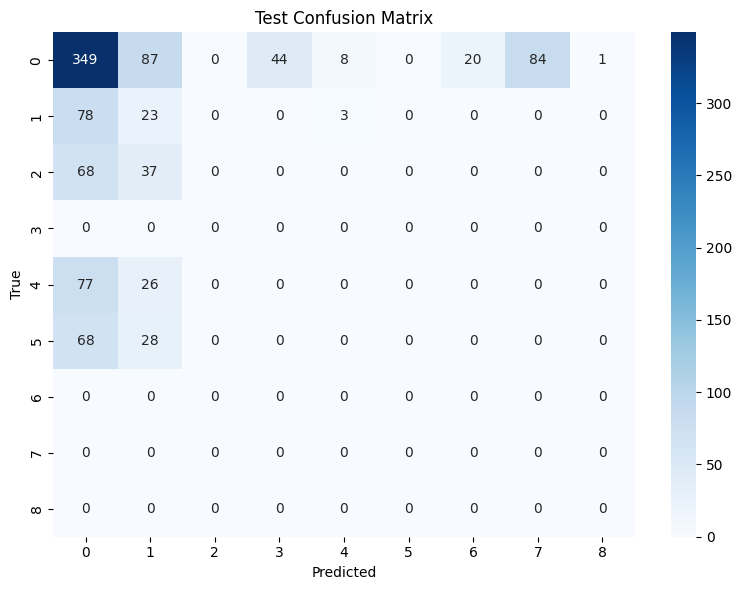

(0.37162837162837165, 0.07965762419912634)

In [20]:
evaluate_on_test_fixed(
    model_path="WeightedRandomSampler_LSTM.pth",
    X_sensor=X_test_sensor_clipped,
    X_tabular=X_test_tab_scaled[:, :3],  # ensure only 3 columns
    y_true=y_test,
    hidden_size=134,
    dropout=0.38931119021527205,
    tabular_dim=3
)
